<a href="https://colab.research.google.com/github/achalu/oro/blob/main/Student_Performance_prediction%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
#import pandas as pd
#!pip install pgmpy
#!pip install numpy
#!apt-get install
#!apt-get -qq install -y libfluidsynth1
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import pydot
#import matplotlib.pyplot as plt
import seaborn as sns
# =====================================================
# STUDENT PERFORMANCE PREDICTION USING BAYESIAN NETWORK
# =====================================================

#Install required library
#!pip install pgmpy -q
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator as DiscreteMLE
from pgmpy.inference import VariableElimination


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
E: Package 'libfluidsynth1' has no installation candidate


In [7]:
data = pd.read_csv('/content/StudentPerformanceFactors.csv')

print(data.shape)

data.head()

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [8]:
data.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [11]:
import pandas as pd
data = pd.DataFrame(data)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [20]:
import pandas as pd

data = pd.read_csv('/content/StudentPerformanceFactors.csv')

# 1. Handle missing values across columns
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].mean(), inplace=True)

# 2. Define the performance category function (Un-nested and properly aligned)
def performance_category(score):
    if score < 60:
        return 'Low'
    elif score < 80:
        return 'Medium'
    else:
        return 'High'

# 3. Create the categorical target
data['Performance'] = data['Exam_Score'].apply(performance_category)

# Drop original score column (Optional depending on experiment)
# data.drop('Exam_Score', axis=1, inplace=True)

/tmp/ipykernel_80676/2958916439.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)
/tmp/ipykernel_80676/2958916439.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [22]:
# ENCODE CATEGORICAL VARIABLES
# ==========================================

label_encoders = {}

for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le


In [23]:
# SELECT FEATURES
# ==========================================

selected_columns = [
    'Hours_Studied',
    'Attendance',
    'Previous_Scores',
    'Motivation_Level',
    'Teacher_Quality',
    'Tutoring_Sessions',
    'Performance'
]

In [24]:
# Discretize numerical columns
for col in ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions']:
    data[col] = pd.qcut(data[col], q=3, labels=False, duplicates='drop')

bn_data = data[selected_columns]

print(bn_data.head())

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

train_data, test_data = train_test_split(
    bn_data,
    test_size=0.2,
    random_state=42
)

   Hours_Studied  Attendance  Previous_Scores  Motivation_Level  \
0              1           1                1                 1   
1              1           0                0                 1   
2              2           2                2                 2   
3              2           2                2                 2   
4              1           2                0                 2   

   Teacher_Quality  Tutoring_Sessions  Performance  
0                2                  0            2  
1                2                  1            2  
2                2                  1            2  
3                2                  0            2  
4                0                  2            2  


In [52]:
model = DiscreteBayesianNetwork([
    ('Hours_Studied', 'Performance'),
    ('Attendance', 'Performance'),
    ('Previous_Scores', 'Performance'),
    ('Motivation_Level', 'Hours_Studied'),
    ('Teacher_Quality', 'Performance'),
    ('Tutoring_Sessions', 'Performance')
])

In [54]:
model.fit(train_data)

print("Model trained successfully")

# ==========================================
# INFERENCE
# ==========================================

inference = VariableElimination(model)

# Example query
query_result = inference.query(
    variables=['Performance'],
    evidence={
        'Hours_Studied': 2,
        'Attendance': 2,
        'Previous_Scores': 2
    }
)

print(query_result)


Model trained successfully
+----------------+--------------------+
| Performance    |   phi(Performance) |
+================+====================+
| Performance(0) |             0.0345 |
+----------------+--------------------+
| Performance(1) |             0.0000 |
+----------------+--------------------+
| Performance(2) |             0.9655 |
+----------------+--------------------+


In [56]:
# 1. Select only the columns that your model uses as features/evidence
# (Make sure these column names exactly match your network's nodes)
evidence_columns = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Teacher_Quality', 'Tutoring_Sessions']
X_test = test_data[evidence_columns]

# 2. Use the model's built-in fast batch prediction method
print("Predicting batch... Please wait a few seconds...")
predictions_df = model.predict(X_test)

# 3. Extract your predicted list and actual list for evaluation
predictions = predictions_df['Performance'].tolist()
actual = test_data['Performance'].tolist()

print("Predictions completed successfully!")

Predicting batch... Please wait a few seconds...


  0%|          | 0/217 [00:00<?, ?it/s]

Predictions completed successfully!


In [57]:
# EVALUATION
# ==========================================

accuracy = accuracy_score(actual, predictions)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(actual, predictions))

Accuracy: 0.9863842662632375

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.00      0.00      0.00        11
           2       0.99      1.00      0.99      1304

    accuracy                           0.99      1322
   macro avg       0.33      0.33      0.33      1322
weighted avg       0.97      0.99      0.98      1322



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


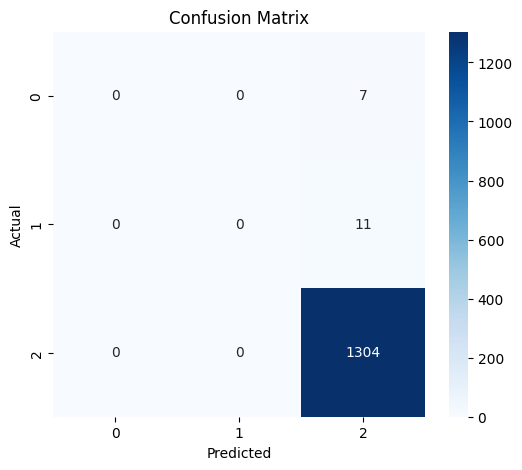

In [58]:
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(actual, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


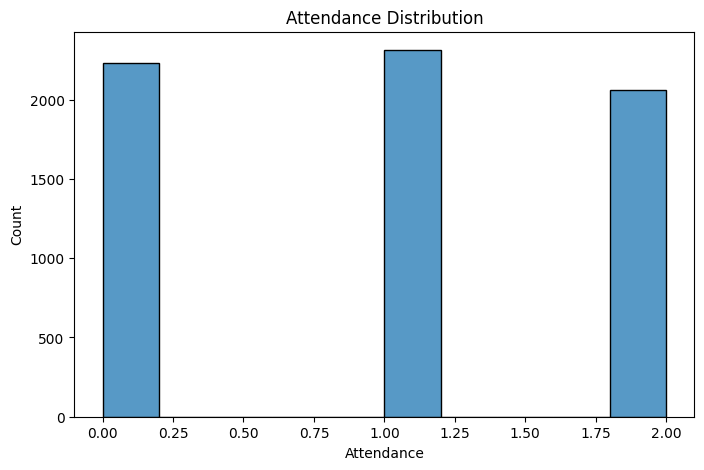

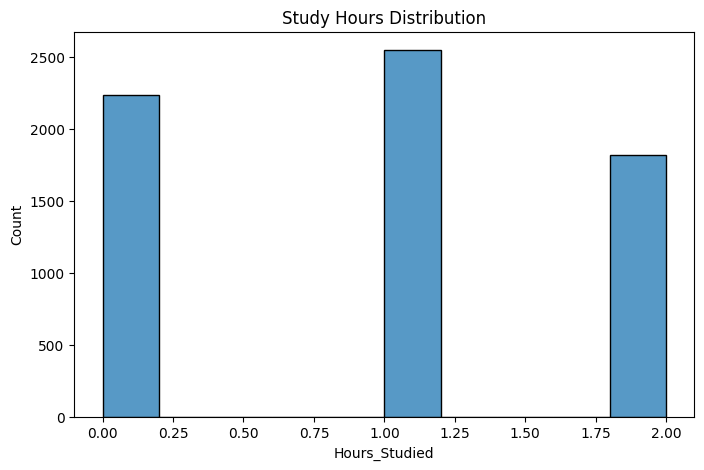

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(data['Attendance'], bins=10)
plt.title('Attendance Distribution')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data['Hours_Studied'], bins=10)
plt.title('Study Hours Distribution')
plt.show()

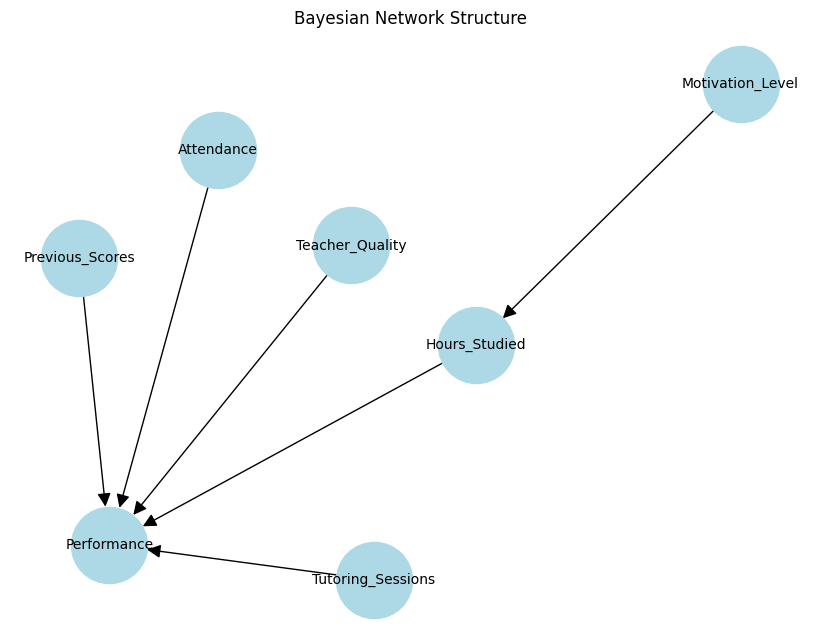

Project completed successfully


In [61]:
import networkx as nx

plt.figure(figsize=(8,6))
G = nx.DiGraph()
G.add_edges_from(model.edges())

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color='lightblue',
    font_size=10,
    arrowsize=20
)

plt.title('Bayesian Network Structure')
plt.show()

print("Project completed successfully")

In [25]:
data.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,...,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,0.936734,0.974572,1.220070,1.203421,0.596035,7.02906,0.982897,1.307553,0.924474,0.632814,...,1.311185,0.695929,1.190858,2.967610,0.105191,0.896473,1.498411,0.577267,67.235659,1.975178
std,0.781015,0.805834,0.865634,0.871783,0.490728,1.46812,0.824895,0.782515,0.264258,0.784655,...,0.896574,0.460048,0.755876,1.031231,0.306823,0.698511,0.670260,0.494031,3.890456,0.196830
min,0.000000,0.000000,0.000000,0.000000,0.000000,4.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,6.00000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000,65.000000,2.000000
50%,1.000000,1.000000,2.000000,2.000000,1.000000,7.00000,1.000000,2.000000,1.000000,0.000000,...,2.000000,1.000000,1.000000,3.000000,0.000000,1.000000,2.000000,1.000000,67.000000,2.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,8.00000,2.000000,2.000000,1.000000,1.000000,...,2.000000,1.000000,2.000000,4.000000,0.000000,1.000000,2.000000,1.000000,69.000000,2.000000
max,2.000000,2.000000,2.000000,2.000000,1.000000,10.00000,2.000000,2.000000,1.000000,2.000000,...,2.000000,1.000000,2.000000,6.000000,1.000000,2.000000,2.000000,1.000000,101.000000,2.000000


In [14]:
data.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


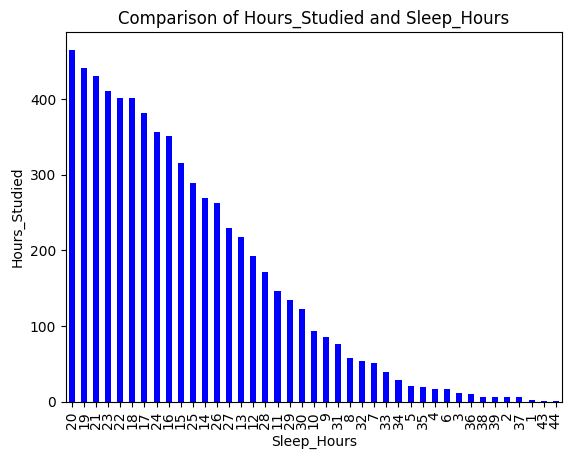

In [9]:
# visualising the number of male and female in the dataset

data['Sleep_Hours'].value_counts(normalize = True)
data['Hours_Studied'].value_counts(dropna = False).plot.bar(color = 'blue')
plt.title('Comparison of Hours_Studied and Sleep_Hours')
plt.xlabel('Sleep_Hours')
plt.ylabel('Hours_Studied')
plt.show()

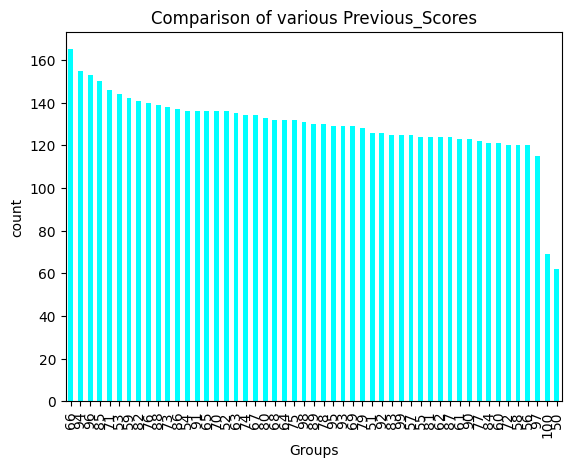

In [11]:
# visualizing the different groups in the dataset

data['Previous_Scores'].value_counts(normalize = True)
data['Previous_Scores'].value_counts(dropna = False).plot.bar(color = 'cyan')
plt.title('Comparison of various Previous_Scores')
plt.xlabel('Groups')
plt.ylabel('count')
plt.show()

In [12]:
data['Previous_Scores'].value_counts()

,count
Previous_Scores,
66,165
94,155
96,153
85,150
71,146
53,144
59,142
82,141
76,140


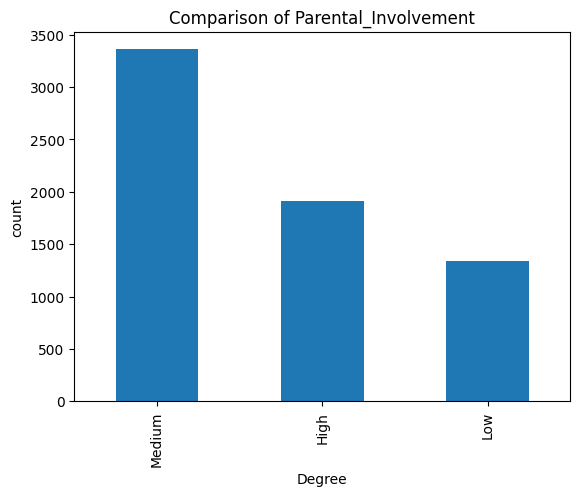

In [15]:
# visualizing the differnt parental education levels

data['Parental_Involvement'].value_counts(normalize = True)
data['Parental_Involvement'].value_counts(dropna = False).plot.bar()
plt.title('Comparison of Parental_Involvement')
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

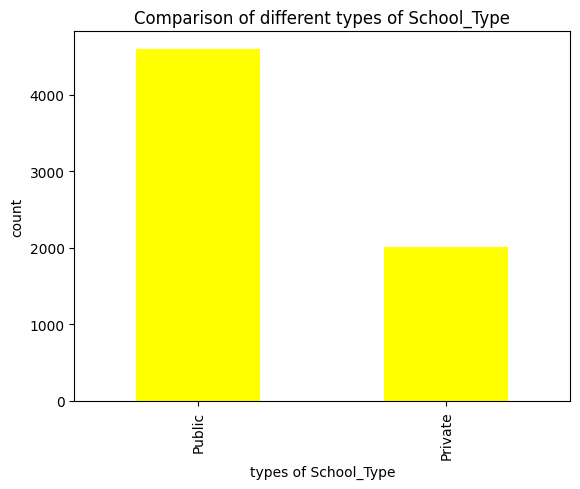

In [17]:
# visualizing different types of School_Type

data['School_Type'].value_counts(normalize = True)
data['School_Type'].value_counts(dropna = False).plot.bar(color = 'yellow')
plt.title('Comparison of different types of School_Type')
plt.xlabel('types of School_Type')
plt.ylabel('count')
plt.show()

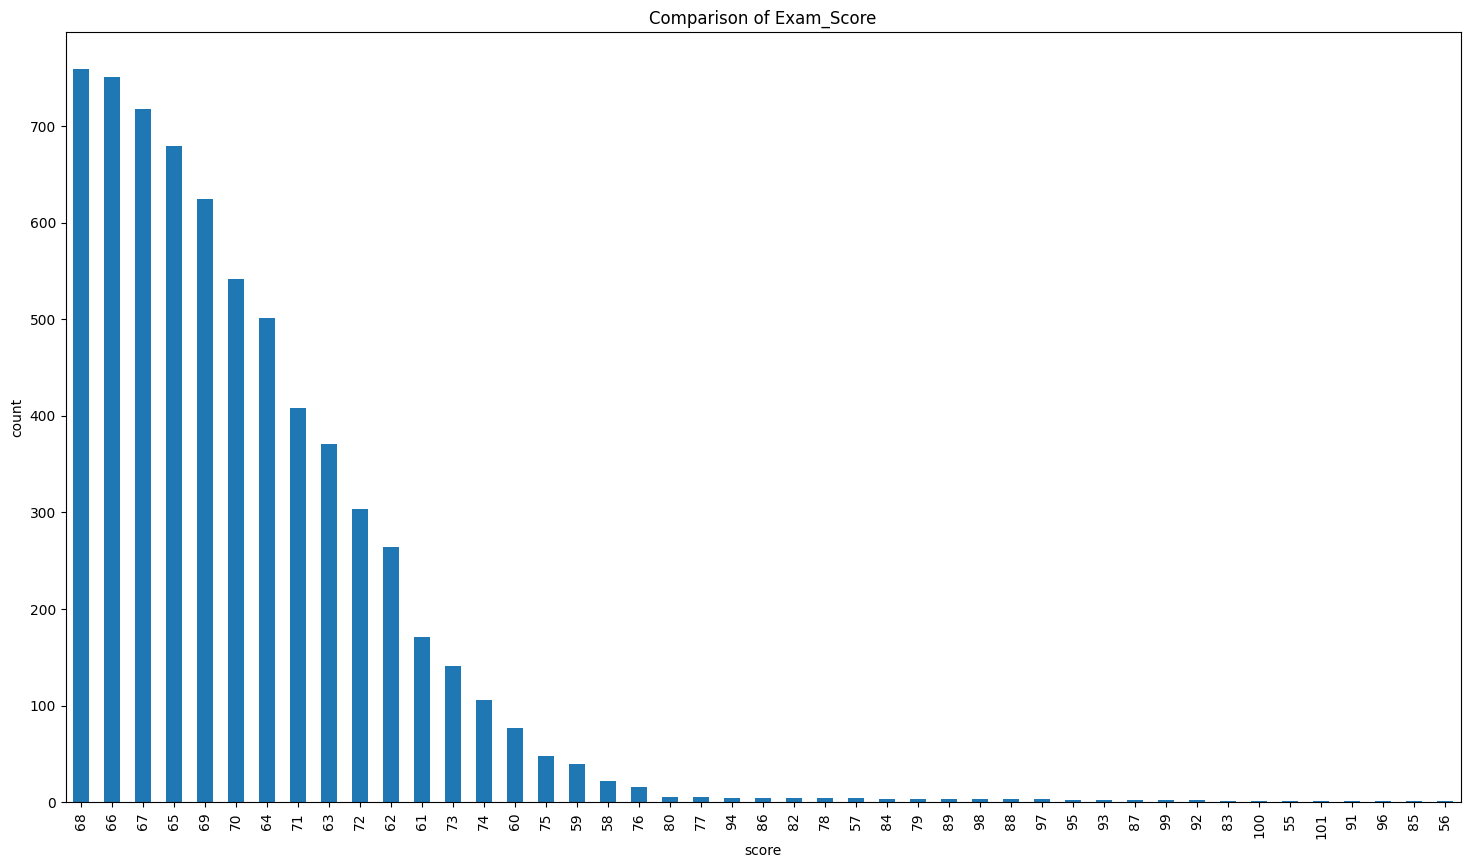

In [19]:
# visualizing maths score

data['Exam_Score'].value_counts(normalize = True)
data['Exam_Score'].value_counts(dropna = False).plot.bar(figsize = (18, 10))
plt.title('Comparison of Exam_Score')
plt.xlabel('score')
plt.ylabel('')
plt.show()

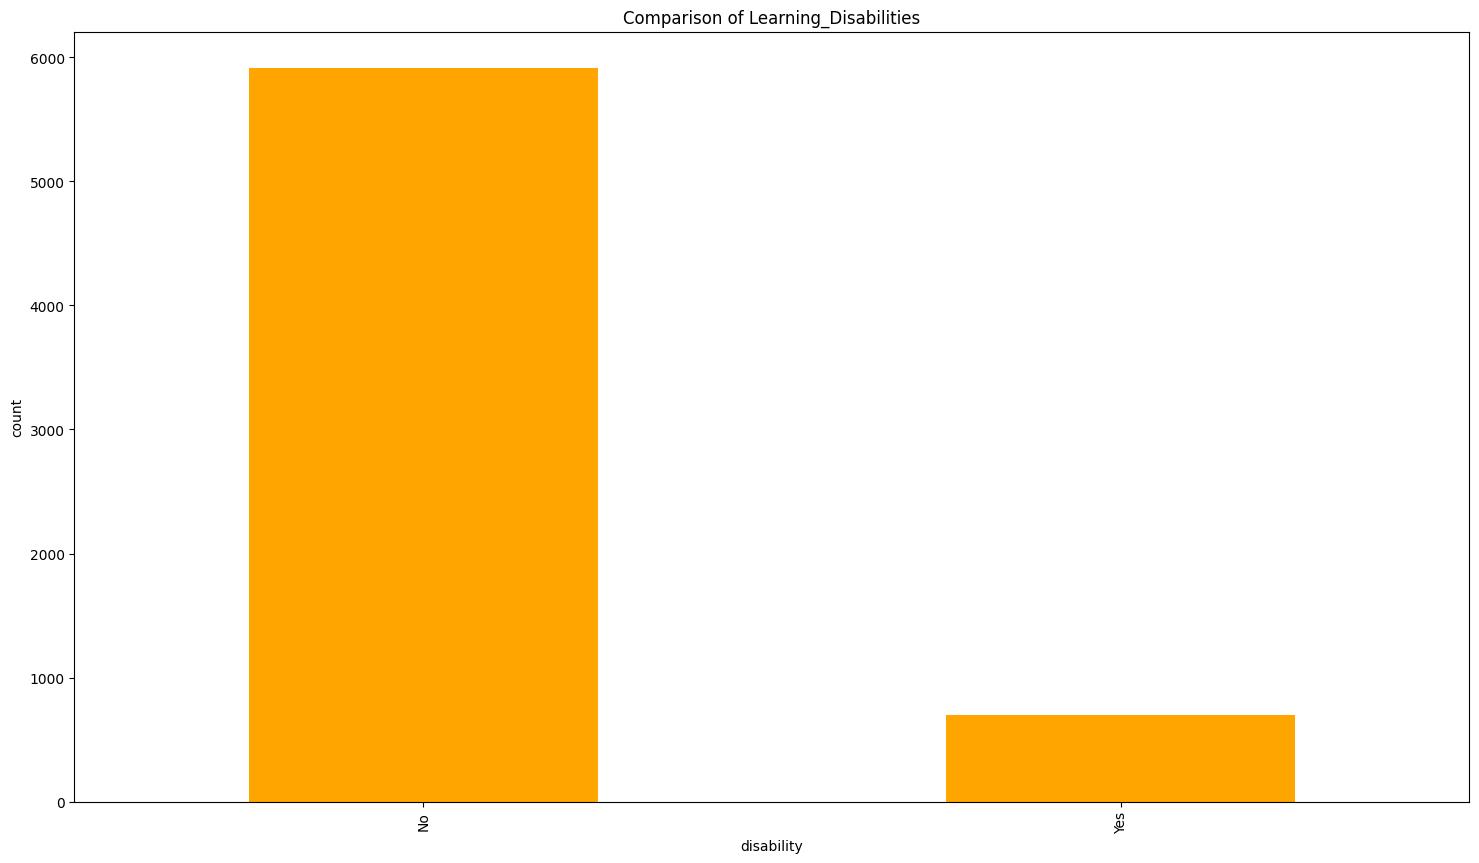

In [34]:
# visualizing Learning_Disabilities score

data['Learning_Disabilities'].value_counts(normalize = True)
data['Learning_Disabilities'].value_counts(dropna = False).plot.bar(figsize = (18, 10), color = 'orange')
plt.title('Comparison of Learning_Disabilities')
plt.xlabel('disability')
plt.ylabel('count')
plt.show()

<Axes: xlabel='Exam_Score'>

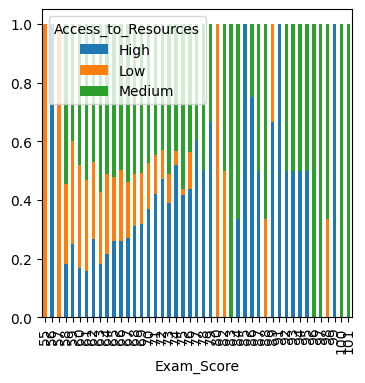

In [40]:
# exam_Score vs Access_to_Resources

x = pd.crosstab(data['Exam_Score'], data['Access_to_Resources'])
x.div(x.sum(1).astype(float), axis = 0).plot(kind = 'bar', stacked = True, figsize = (4, 4))

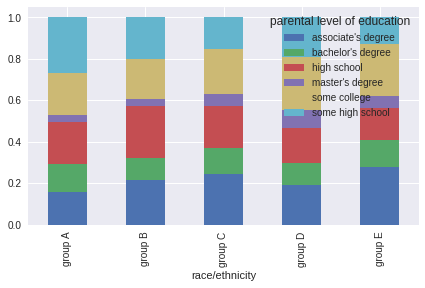

In [ ]:
# comparison of race/ethnicity and parental level of education

x = pd.crosstab(data['race/ethnicity'], data['parental level of education'])
x.div(x.sum(1).astype(float), axis = 0).plot(kind = 'bar', stacked = 'True', figsize = (7, 4) )

/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:1468: FutureWarning: remove_na is deprecated and is a private function. Do not use.
  stat_data = remove_na(group_data[hue_mask])


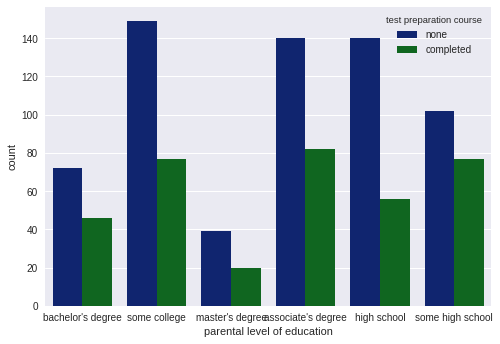

In [ ]:
# comparison of Parental_Involvement and Hours_Studied

sns.countplot(x = 'Parental_Involvement', data = data, hue = 'Hours_Studied', palette = 'dark')
plt.show()

/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:1468: FutureWarning: remove_na is deprecated and is a private function. Do not use.
  stat_data = remove_na(group_data[hue_mask])


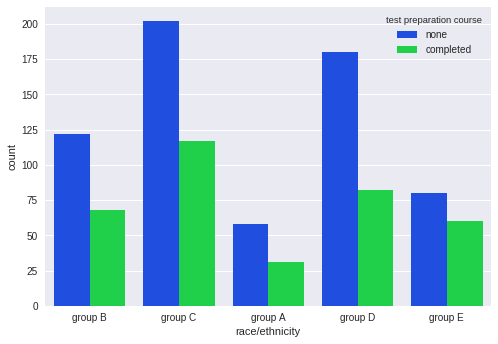

In [ ]:
# comparison of race/ethnicity and test preparation course

sns.countplot(x = 'race/ethnicity', data = data,  hue = 'test preparation course', palette = 'bright')
plt.show()

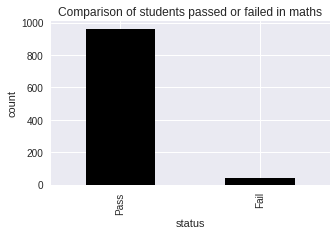

In [ ]:
# feature engineering on the data to visualize and solve the dataset more accurately

# setting a passing mark for the students to pass on the three subjects individually
passmarks = 40

# creating a new column pass_math, this column will tell us whether the students are pass or fail
data['pass_math'] = np.where(data['math score']< passmarks, 'Fail', 'Pass')
data['pass_math'].value_counts(dropna = False).plot.bar(color = 'black', figsize = (5, 3))

plt.title('Comparison of students passed or failed in maths')
plt.xlabel('status')
plt.ylabel('count')
plt.show()

In [ ]:
data['pass_math'].value_counts()

Pass    960
Fail     40
Name: pass_math, dtype: int64

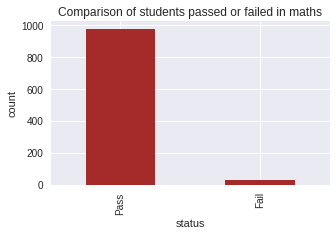

In [ ]:
# creating a new column pass_math, this column will tell us whether the students are pass or fail
data['pass_reading'] = np.where(data['reading score']< passmarks, 'Fail', 'Pass')
data['pass_reading'].value_counts(dropna = False).plot.bar(color = 'brown', figsize = (5, 3))

plt.title('Comparison of students passed or failed in maths')
plt.xlabel('status')
plt.ylabel('count')
plt.show()

In [ ]:
data['pass_reading'].value_counts(dropna = False)

Pass    974
Fail     26
Name: pass_reading, dtype: int64

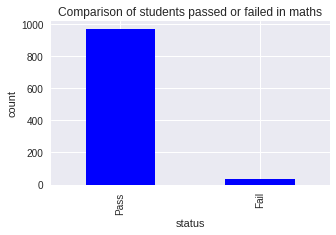

In [ ]:
# creating a new column pass_math, this column will tell us whether the students are pass or fail
data['pass_writing'] = np.where(data['writing score']< passmarks, 'Fail', 'Pass')
data['pass_writing'].value_counts(dropna = False).plot.bar(color = 'blue', figsize = (5, 3))

plt.title('Comparison of students passed or failed in maths')
plt.xlabel('status')
plt.ylabel('count')
plt.show()

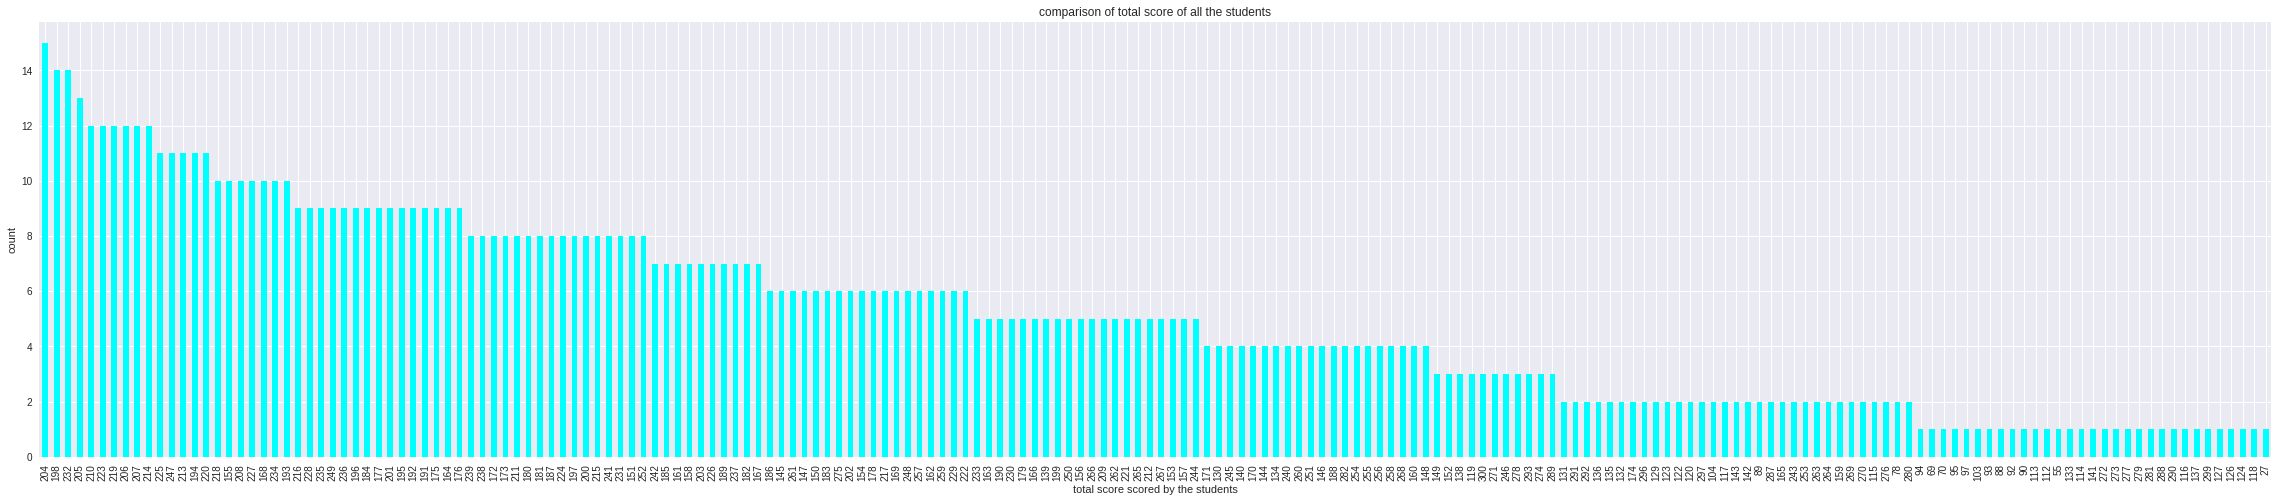

In [ ]:
# computing the total score for each student

data['total_score'] = data['math score'] + data['reading score'] + data['writing score']

data['total_score'].value_counts(normalize = True)
data['total_score'].value_counts(dropna = True).plot.bar(color = 'cyan', figsize = (40, 8))

plt.title('comparison of total score of all the students')
plt.xlabel('total score scored by the students')
plt.ylabel('count')
plt.show()

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


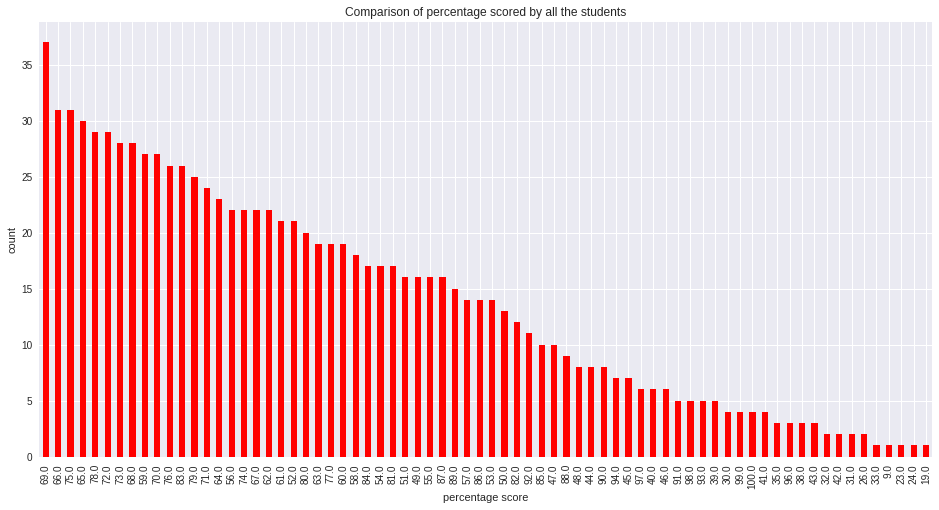

In [ ]:
# computing percentage for each of the students
# importing math library to use ceil
from math import *

data['percentage'] = data['total_score']/3

for i in range(0, 1000):
  data['percentage'][i] = ceil(data['percentage'][i])

data['percentage'].value_counts(normalize = True)
data['percentage'].value_counts(dropna = False).plot.bar(figsize = (16, 8), color = 'red')

plt.title('Comparison of percentage scored by all the students')
plt.xlabel('percentage score')
plt.ylabel('count')
plt.show()

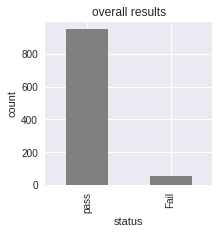

In [ ]:
# checking which student is fail overall

data['status'] = data.apply(lambda x : 'Fail' if x['pass_math'] == 'Fail' or
                           x['pass_reading'] == 'Fail' or x['pass_writing'] == 'Fail'
                           else 'pass', axis = 1)

data['status'].value_counts(dropna = False).plot.bar(color = 'gray', figsize = (3, 3))
plt.title('overall results')
plt.xlabel('status')
plt.ylabel('count')
plt.show()

In [ ]:
# Assigning grades to the grades according to the following criteria :
# 0  - 40 marks : grade E
# 41 - 60 marks : grade D
# 60 - 70 marks : grade C
# 70 - 80 marks : grade B
# 80 - 90 marks : grade A
# 90 - 100 marks : grade O

def getgrade(percentage, status):
  if status == 'Fail':
    return 'E'
  if(percentage >= 90):
    return 'O'
  if(percentage >= 80):
    return 'A'
  if(percentage >= 70):
    return 'B'
  if(percentage >= 60):
    return 'C'
  if(percentage >= 40):
    return 'D'
  else :
    return 'E'

data['grades'] = data.apply(lambda x: getgrade(x['percentage'], x['status']), axis = 1 )

data['grades'].value_counts()

B    260
C    252
D    223
A    156
O     58
E     51
Name: grades, dtype: int64

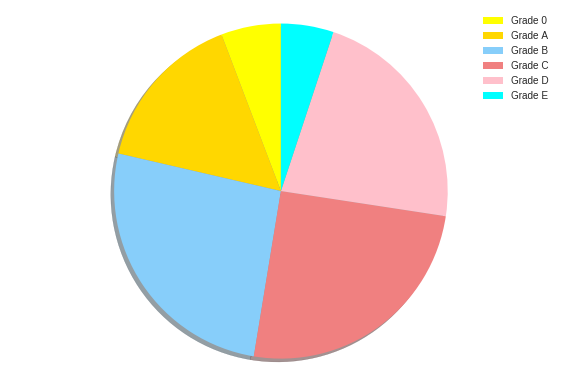

In [ ]:
# plotting a pie chart for the distribution of various grades amongst the students

labels = ['Grade 0', 'Grade A', 'Grade B', 'Grade C', 'Grade D', 'Grade E']
sizes = [58, 156, 260, 252, 223, 51]
colors = ['yellow', 'gold', 'lightskyblue', 'lightcoral', 'pink', 'cyan']
explode = (0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001)

patches, texts = plt.pie(sizes, colors=colors, shadow=True, startangle=90)
plt.legend(patches, labels)
plt.axis('equal')
plt.tight_layout()
plt.show()

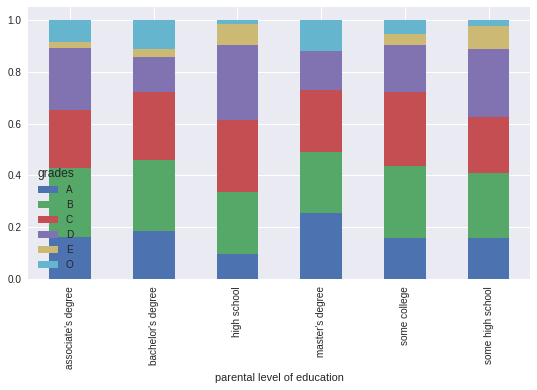

In [ ]:
# comparison parent's degree and their corresponding grades

x = pd.crosstab(data['parental level of education'], data['grades'])
x.div(x.sum(1).astype(float), axis = 0).plot(kind = 'bar', stacked = True, figsize = (9, 5))

/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:1468: FutureWarning: remove_na is deprecated and is a private function. Do not use.
  stat_data = remove_na(group_data[hue_mask])


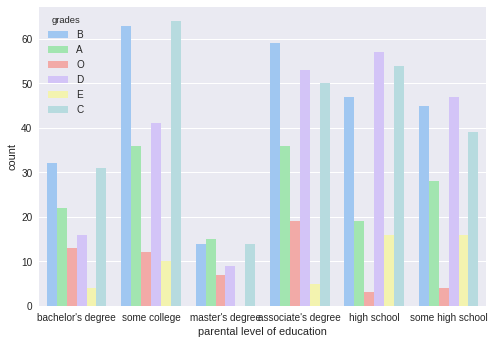

In [ ]:
# for better visualization we will plot it again using seaborn

sns.countplot(x = data['parental level of education'], data = data, hue = data['grades'], palette = 'pastel')
plt.show()

/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:1468: FutureWarning: remove_na is deprecated and is a private function. Do not use.
  stat_data = remove_na(group_data[hue_mask])


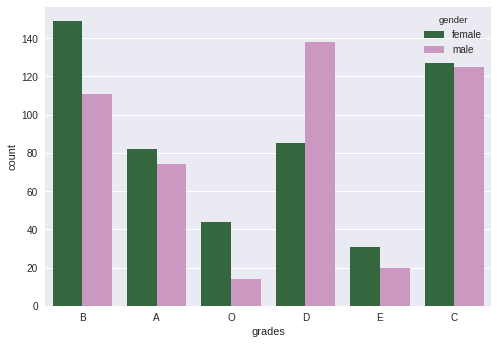

In [ ]:
# comparing the distribution of grades among males and females

sns.countplot(x = data['grades'], data = data, hue = data['gender'], palette = 'cubehelix')
#sns.palplot(sns.dark_palette('purple'))
plt.show()

In [ ]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_math,pass_reading,pass_writing,total_score,percentage,status,grades
0,female,group B,bachelor's degree,standard,none,72,72,74,Pass,Pass,Pass,218,73.0,pass,B
1,female,group C,some college,standard,completed,69,90,88,Pass,Pass,Pass,247,83.0,pass,A
2,female,group B,master's degree,standard,none,90,95,93,Pass,Pass,Pass,278,93.0,pass,O
3,male,group A,associate's degree,free/reduced,none,47,57,44,Pass,Pass,Pass,148,50.0,pass,D
4,male,group C,some college,standard,none,76,78,75,Pass,Pass,Pass,229,77.0,pass,B


In [ ]:
data.describe()

,math score,reading score,writing score,total_score,percentage
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,68.105000
std,15.16308,14.600192,15.195657,42.771978,14.258095
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,59.000000
50%,66.00000,70.000000,69.000000,205.000000,69.000000
75%,77.00000,79.000000,79.000000,233.000000,78.000000
max,100.00000,100.000000,100.000000,300.000000,100.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

# creating an encoder
le = LabelEncoder()

# label encoding for test preparation course
data['test preparation course'] = le.fit_transform(data['test preparation course'])
data['test preparation course'].value_counts()

1    642
0    358
Name: test preparation course, dtype: int64

In [ ]:
# label encoding for lunch

data['lunch'] = le.fit_transform(data['lunch'])
data['lunch'].value_counts()

1    645
0    355
Name: lunch, dtype: int64

In [ ]:
# label encoding for race/ethnicity
# we have to map values to each of the categories

data['race/ethnicity'] = data['race/ethnicity'].replace('group A', 1)
data['race/ethnicity'] = data['race/ethnicity'].replace('group B', 2)
data['race/ethnicity'] = data['race/ethnicity'].replace('group C', 3)
data['race/ethnicity'] = data['race/ethnicity'].replace('group D', 4)
data['race/ethnicity'] = data['race/ethnicity'].replace('group E', 5)

data['race/ethnicity'].value_counts()

3    319
4    262
2    190
5    140
1     89
Name: race/ethnicity, dtype: int64

In [ ]:
# label encoding for parental level of education

data['parental level of education'] = le.fit_transform(data['parental level of education'])
data['parental level of education'].value_counts()

4    226
0    222
2    196
5    179
1    118
3     59
Name: parental level of education, dtype: int64

In [ ]:
# label encoding for gender

data['gender'] = le.fit_transform(data['gender'])
data['gender'].value_counts()

0    518
1    482
Name: gender, dtype: int64

In [ ]:
# label encoding for pass_math

data['pass_math'] = le.fit_transform(data['pass_math'])
data['pass_math'].value_counts()

1    960
0     40
Name: pass_math, dtype: int64

In [ ]:
# label encoding for pass_reading

data['pass_reading'] = le.fit_transform(data['pass_reading'])
data['pass_reading'].value_counts()

1    974
0     26
Name: pass_reading, dtype: int64

In [ ]:
# label encoding for pass_writing

data['pass_writing'] = le.fit_transform(data['pass_writing'])
data['pass_writing'].value_counts()

1    968
0     32
Name: pass_writing, dtype: int64

In [ ]:
# label encoding for status

data['status'] = le.fit_transform(data['status'])
data['status'].value_counts()

1    949
0     51
Name: status, dtype: int64

In [ ]:
# label encoding for grades
# we have to map values to each of the categories

data['grades'] = data['grades'].replace('O', 0)
data['grades'] = data['grades'].replace('A', 1)
data['grades'] = data['grades'].replace('B', 2)
data['grades'] = data['grades'].replace('C', 3)
data['grades'] = data['grades'].replace('D', 4)
data['grades'] = data['grades'].replace('E', 5)

data['race/ethnicity'].value_counts()

3    319
4    262
2    190
5    140
1     89
Name: race/ethnicity, dtype: int64

In [ ]:
data.shape

(1000, 15)

In [ ]:
# splitting the dependent and independent variables

x = data.iloc[:,:14]
y = data.iloc[:,14]

print(x.shape)
print(y.shape)

(1000, 14)
(1000,)


In [ ]:
# splitting the dataset into training and test sets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 45)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(750, 14)
(750,)
(250, 14)
(250,)
